Wir arbeiten im Folgenden mit dem USPS (United States Postal Service) Datensatz, der 16x16 Grauwertbilder von handgeschriebenen Ziffern (0-9) enthält.

![title](https://git-disl.github.io/GTDLBench/figures/usps.png)

1.) Laden Sie zunächst die Daten aus der zur verfügbar gestellten Datei. Passen Sie den Pfad entsprechend an.


In [77]:
import h5py
import numpy as np

# load the data
f = h5py.File("../doc/usps_data.hdf5",'r+')
trainX = np.array(f.get('trainX'))
trainY = np.array(f.get('trainY'))
testX = np.array(f.get('testX'))
testY = np.array(f.get('testY'))
f.close()


trainX enthält N Trainingsbeispiele (Zeilen) mit p Merkmalen (Anzahl Features):

In [78]:
[N_train, p] = trainX.shape
print(f"Anzahl Trainingsbeispiele: {N_train} mit {p} Features/Merkmalen")

Anzahl Trainingsbeispiele: 10000 mit 256 Features/Merkmalen


Hierbei sind die 256 Features die Grauwerte der 16x16 Pixel der Bilder der Ziffern.

Analog kann man das für testX, die zugehörigen Testbeispiele, abfragen:

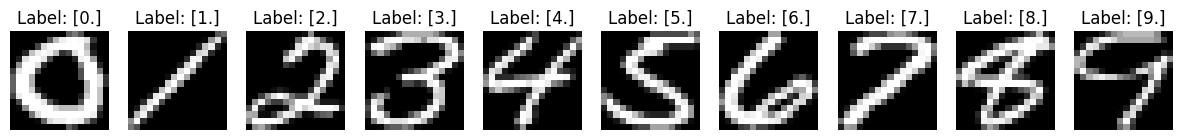

In [79]:
# todo
import matplotlib.pyplot as plt
# Visualisierung 1 zufälliges Trainingsbeispiel für jede Klasse mit Seed für Reproduzierbarkeit
np.random.seed(42)
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    idx = np.random.choice(np.where(trainY == i)[0])
    axes[i].imshow(trainX[idx].reshape(16, 16).transpose(), cmap='gray')
    axes[i].set_title(f"Label: {trainY[idx]}")
    axes[i].axis('off')
plt.show()

trainY und testY enthalten die zugehörigen Labels. Geben Sie die Anzahl der Labels für die Trainingsdaten und Testdaten aus.

In [80]:
# Anzahl der Beispiele pro Klasse in trainY und testY
train_counts = np.bincount(trainY.astype(int).ravel(), minlength=10)
test_counts = np.bincount(testY.astype(int).ravel(), minlength=10)

print("Anzahl der Beispiele pro Klasse in trainY:")
for i, count in enumerate(train_counts):
    print(f"Klasse {i}: {count} Beispiele")

print("\nAnzahl der Beispiele pro Klasse in testY:")
for i, count in enumerate(test_counts):
    print(f"Klasse {i}: {count} Beispiele")

Anzahl der Beispiele pro Klasse in trainY:
Klasse 0: 1000 Beispiele
Klasse 1: 1000 Beispiele
Klasse 2: 1000 Beispiele
Klasse 3: 1000 Beispiele
Klasse 4: 1000 Beispiele
Klasse 5: 1000 Beispiele
Klasse 6: 1000 Beispiele
Klasse 7: 1000 Beispiele
Klasse 8: 1000 Beispiele
Klasse 9: 1000 Beispiele

Anzahl der Beispiele pro Klasse in testY:
Klasse 0: 100 Beispiele
Klasse 1: 100 Beispiele
Klasse 2: 100 Beispiele
Klasse 3: 100 Beispiele
Klasse 4: 100 Beispiele
Klasse 5: 100 Beispiele
Klasse 6: 100 Beispiele
Klasse 7: 100 Beispiele
Klasse 8: 100 Beispiele
Klasse 9: 100 Beispiele


Die gelabeleten Trainingsdaten sind sortiert: Zunächst haben wir 1000 Beispiele für die Ziffer 1, dann 1000 Beispiele für die Ziffer 2, ..., zuletzt für die Ziffern 9 und 0:

In [81]:
print(trainY)
print(trainY.shape)

[[1.]
 [1.]
 [1.]
 ...
 [0.]
 [0.]
 [0.]]
(10000, 1)


2.) Nun betrachten wir ein paar Beispiele. Zunächst visualisieren wir das erste Beispiel für die Klasse 2. Hierzu verwenden wir matpolotlib. 

Mittels reshape machen wir aus dem 1x256 Vektor wieder ein Bild. Transpose sorgt dafür, dass es nicht auf dem Kopf steht.

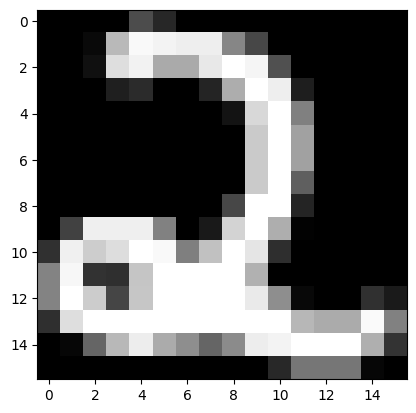

In [82]:
import matplotlib.pyplot as plt

# First sample of number 2
# 1000 is the first index of the class 2 in trainY
plt.imshow(trainX[1000,:].reshape(16,16).transpose(),cmap='gray')
plt.show()

Was machen die Befehle transpose() und reshape()?

Wiederholen Sie dies nun für die folgenden Bilder:
* 3. Beispiel für Ziffer 3
* 1. Beispiel für Ziffer 0

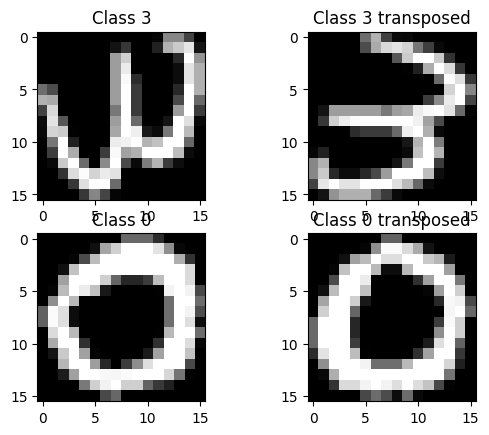

In [83]:
# todo
fig, axes = plt.subplots(2, 2)

# Class 3
axes[0][0].imshow(trainX[2000,:].reshape(16,16),cmap='gray')
axes[0][0].set_title('Class 3')
# Class 0
axes[0][1].imshow(trainX[2000,:].reshape(16,16).transpose(),cmap='gray')
axes[0][1].set_title('Class 3 transposed')
# Class 1
axes[1][0].imshow(trainX[9000,:].reshape(16,16),cmap='gray')
axes[1][0].set_title('Class 0')
# Class 2
axes[1][1].imshow(trainX[9000,:].reshape(16,16).transpose(),cmap='gray')
axes[1][1].set_title('Class 0 transposed')

plt.show()

Plotten Sie nun den Mittelwert für jede einzelne Ziffer als Bild. Nutzen Sie den Befehl "where" aus numpy, um die entsprechenden Zeilen zu extrahieren, bevor Sie den Mittelwert (Befehl mean in numpy) bilden und das Bild anschließend reshapen.

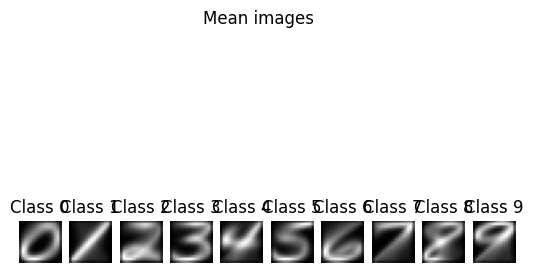

In [84]:
fig, axs = plt.subplots(1,10)
fig.suptitle('Mean images')
for i in range(0,10):

    #todo
    class_values = np.where(trainY == i, trainX, 0)
    mean_image = class_values.sum(axis=0) / np.sum(trainY == i)
    axs[i].imshow(mean_image.reshape(16,16).transpose(), cmap='gray')
    axs[i].set_title(f'Class {i}')
    axs[i].axis('off')
    
plt.show()

3.) Schreiben Sie nun eine Funktion 

def euclidean_distance_2loops(data1: np.array, data2: np.array)

die die euklidische Distanz zwischen allen Trainingsbildern (-vektoren) und Testbildern (-vektoren) aus berechnet. Als Eingabe dienen also zwei nd-arrays der Größen N_train x p und N_test x p (N_train ist die Anzahl der Trainingsbeispiele/Samples in data1, N_test ist die Anzahl der Testbeispiele/Samples in data2, p ist die Dimension der Daten/Anzahl der Features). Die Ausgabe ist ein N_train x N_test nd-array mit den paarweisen Distanzen. 

Die Funktion soll jeweils eine Schleife für die Beispiele in data1 und data2 verwenden. 

Machen Sie sich zunächst klar, was ein Eintrag in den nd-arrays data1, data2 und distances bedeutet. Implementieren Sie dann die Methode.
Nützliche Befehle:  sqrt(A), sum, zeros((m, n)), square aus numpy


In [85]:
import numpy as np

# TODO
def euclidean_distance(data1: np.array, data2: np.array):
    data1 = np.atleast_2d(data1) # ensure that the input has 2 dimensions, i.e. convert possible (1000,) to (1000,1)
    data2 = np.atleast_2d(data2)
    # Save dimensions of the input data
    n1, m1 = data1.shape
    n2, m2 = data2.shape
    # print(f"data1: {n1} examples with {m1} features, data2: {n2} examples with {m2} features")

    # Compute the squared differences and sum them up
    results = np.zeros((n1, n2))
    for d1 in range(n1):
        for d2 in range(n2):
            squared_distance = np.sum((data1[d1] - data2[d2]) ** 2)
            results[d1, d2] = np.sqrt(squared_distance)
    return results

Testen Sie die Funktion zunächst mit Daten, für die Sie die Lösung einfach auch selbst berechnen können. Skizzieren Sie kurz die Datenpunkte, was sollte herauskommen?

In [86]:
data1 = np.array([[1, 0], [0, 1], [1, 1]])
data2 = np.array([[1, 0], [0, 1]])

distances2 = euclidean_distance(data1, data2)

print(distances2)

[[0.         1.41421356]
 [1.41421356 0.        ]
 [1.         1.        ]]


4.) Betrachten Sie zunächst folgende kNN Implementierung und überlegen Sie sich, was der Klassifikator in den verschiedenen Zeilen tut.

In [87]:
import numpy as np

'''
function that performs a k nearest neighbor classification

input

trainX      N1xp array of N1 training points in p dimensions
trainY      N1x1 array of training point labels (0-9)
testX       N2xp array of N2 test points in p dimensions
k           the number of considered nearest neighbors

output

predictedY  N2x1 array of predicted labels (0-9)

note: this simple code is biased in the sense that lower 
class numbers are favored in case of ties! 
randomization could help here!

'''
def kNN(trainX: np.array, trainY: np.array, testX: np.array, k):
    trainX = np.atleast_2d(trainX)
    testX = np.atleast_2d(testX)
    # 01: TODO: prepare result
    predictedY = np.zeros([testX.shape[0], 1])

    # 02: TODO: calculate distance matrix (N1xN2, i.e. each column refers to one test sample)
    dist = euclidean_distance(trainX, testX)
 
    # 03: TODO: we are now interested in the rows (i.e., training points) with the lowest distances to the test samples
    # with argsort, we do not really sort the matrix along the columns but only retrieve the (row) indices where
    # we can find the closest training samples
    # (true sorting could be done by: sorted = np.take_along_axis(dist, indices, axis=0))
    indices = np.argsort(dist, axis=0)
    
    # 04: TODO: loop over test samples, for each test sample i, find the k nearest neighbors:
    for i in range(0, testX.shape[0]):
        # 05: TODO: get first k entries of the i-th column of the indices matrix
        # and access the corresponding entries in the trainY vector
        first_k_indices = indices[0:k, i]
        labels = trainY[first_k_indices, 0]

        # 06: TODO: calculate a histogram over class labels (here we have the labels 0-9) among
        # the labels of the k nearest neighbors
        # 06a: TODO: first find out which class labels there are
        bins = np.unique(np.asarray(labels))
        # 06b: TODO: add 1 bin to ensure that histo treats this correctly (right boundary) and compute the histogram
        bins = np.append(bins, np.max(bins)+1)
        histo = np.histogram(labels, bins)
        # 07: TODO: do kNN classification:
        # argmax returns the index with the highest number of counts
        # we then check which bin (i.e., label) this corresponds to and set the i-th label accordingly
        predictedY[i] = bins[np.argmax(histo[0])]
    
    return predictedY

# How does Step 03 work?
dist = np.array([
    [4.0, 2.0],
    [1.0, 5.0],
    [3.0, 1.0]
])

step3 = np.argsort(dist, axis=0)
print(step3)
# Spalte (4.0, 1.0, 3.0) -> sortiert: (1.0, 3.0, 4.0) -> Indizes: (1, 2, 0)


[[1 2]
 [2 0]
 [0 1]]


5.) Nun wenden wir den kNN Klassifikator an. Untersuchen Sie, welche Klassifikationsergebnisse Sie für die folgenden Test-Beispiele erhalten, die der Klassifikator noch nie gesehen hat. Setzen Sie zunächst k=1:

[[1.]
 [3.]
 [0.]]


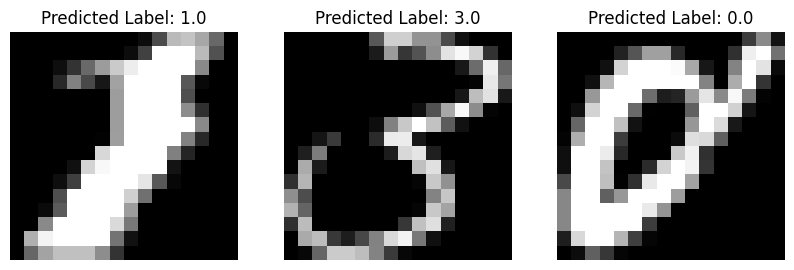

In [88]:
indices = [0,200,978]

# TODO
predictedY = kNN(trainX, trainY, testX[indices], k=3)
print(predictedY)

# Visualize the predicted labels for the test samples with indices 0, 200, and 978
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, idx in enumerate(indices):
    axes[i].imshow(testX[idx].reshape(16, 16).transpose(), cmap='gray')
    axes[i].set_title(f"Predicted Label: {predictedY[i][0]}")
    axes[i].axis('off')
plt.show()

6.) Wir haben einen ersten Klassifikator umgesetzt, der auf Bildern Ziffern erkennen kann! Nun wollen wir aber wissen, wie gut er tatsächlich ist. Dazu reicht es nicht, nur Einzelbilder zu betrachten.

Zunächst nehmen wir aber noch eine Modifikation vor und verwenden eine deutlich effizientere Euklidische Distanzberechnungsfunktion, die eine der drei for Schleifen durch Vektorisierung ersetzt. 

Die Idee dahinter: Vom in der ersten Schleife ausgewählte Sample wird jedes in der zweiten Schleife ausgewählte Sample abgezogen und die Distanz quadriert. Durch Vektorisieren dieser Berechnung können wir uns diese zweite Schleife sparen. Implementieren Sie diese Funktion!
Hinweis: Nutzen Sie die Funktion tile, um das in der ersten Schleife ausgewählte Sample zu replizieren.                                                                                                                          

In [89]:
# TODO
def euclidean_distance_1loop(data1: np.array, data2: np.array):
    data1 = np.atleast_2d(data1) # ensure that the input has 2 dimensions, i.e. convert possible (1000,) to (1000,1)
    data2 = np.atleast_2d(data2)
    # Save dimensions of the input data
    n1, m1 = data1.shape
    n2, m2 = data2.shape
    # print(f"data1: {n1} examples with {m1} features, data2: {n2} examples with {m2} features")

    # Compute the squared differences and sum them up
    results = np.zeros((n1, n2))
    for d1 in range(n1):
        # Do Point - Vector subtraction, i.e. subtract the d1-th point of data1 from all points in data2
        squared_distance = np.sum((data1[d1] - data2) ** 2, axis=1)
        results[d1] = np.sqrt(squared_distance)
    return results

Testen Sie diese Funktion auf den obigen Daten:

In [90]:
data1 = np.array([[1, 0], [0, 1], [1, 1]])
data2 = np.array([[1, 0], [0, 1]])

distances2 = euclidean_distance(data1, data2)
distances1 = euclidean_distance_1loop(data1, data2)

print(distances2)
print(distances1)

[[0.         1.41421356]
 [1.41421356 0.        ]
 [1.         1.        ]]
[[0.         1.41421356]
 [1.41421356 0.        ]
 [1.         1.        ]]


Prüfen Sie nun auf Gleichheit bei den Trainingsdaten und vergleichen Sie die Laufzeit:
Hinweis: Das kann ein paar Minuten dauern!

In [91]:
import time

t = time.time()
distances2 = euclidean_distance(trainX, testX)
elapsed = time.time() - t
print(f'Elapsed time with 2 loops: {elapsed}s')

t = time.time()
distances1 = euclidean_distance_1loop(trainX, testX)
elapsed = time.time() - t
print(f'Elapsed time with 1 loop:  {elapsed}s')

print(f'Maximum deviation between method with 2 loops and method with 1 loop:  {np.max(distances2-distances1)}')


Elapsed time with 2 loops: 45.55338096618652s
Elapsed time with 1 loop:  11.559865474700928s
Maximum deviation between method with 2 loops and method with 1 loop:  0.0


Es ist sogar möglich, auf zwei der drei Schleifen zu verzichten und so die Euklidische Distanzberechnung noch effizienter zu machen. Dazu nutzen wir die Binomische Formel (a-b)² = a² -2ab + b²:

Hinweis: Diese Method überschreibt obige Methode, da wir sie künftig im kNN benutzen wollen.

In [92]:
def euclidean_distance(data1: np.array, data2: np.array):
    # dimensions
    data1 = np.atleast_2d(data1)
    data2 = np.atleast_2d(data2)
    [num_samples1, p] = data1.shape
    [num_samples2, p] = data2.shape

    # Euclidean distance: sqrt ( (a-b)^2 )
    # calculate x'*x for each training example x (i.e. for each row of data1
    # respectively data2), results in num_samples1x1 respectively num_samples2x1 matrix
    check = np.square(data1)
    data1_squared = np.sum(np.square(data1), axis=1) # has size num_samples1 x 1
    data2_squared = np.sum(np.square(data2), axis=1) # has size num_samples2 x 1
    data1_squared = data1_squared.reshape([data1_squared.shape[0], 1]) # avoid that dimensions are dropped
    data2_squared = data2_squared.reshape([data2_squared.shape[0], 1])

    # Euclidean distance: sqrt ( (a-b)^2 )
    # Use the binomial formula: (a - b) ^ 2 = a ^ 2 - 2ab + b ^ 2!
    a_squared = np.tile(data1_squared, (1, num_samples2)) # replicate data1_squared along cols (num_samples2 repeats) => num_samples1 x num_samples2
    b_squared = np.tile(np.transpose(data2_squared), (num_samples1, 1)) # replicate transposed data2_squared along rows (num_samples1 repeats) => num_samples1 x num_samples2
    mixed_term = 2* data1.dot(np.transpose(data2))
    distances = np.sqrt( a_squared - mixed_term + b_squared )
    return distances

Diese Methode ist deutlich effizienter:

In [93]:
t = time.time()
distances0 = euclidean_distance(trainX, testX)
elapsed = time.time() - t
print(f'Elapsed time with 0 loops: {elapsed}s')

print(f'Maximum deviation between method with 2 loops and method with 0 loops: {np.max(distances2-distances0)}')

Elapsed time with 0 loops: 0.21843886375427246s
Maximum deviation between method with 2 loops and method with 0 loops: 1.9095836023552692e-14


Wenden Sie nun den kNN-Klassifikator auf die gesamten USPS Daten an (k=1, k=2, k=3). Verwenden Sie trainX und trainY als Trainings- und testX als Testdaten. 
Vergleichen Sie die Klassifikationsergebnisse mit den bekannten, korrekten Labels (testY) und berechnen Sie jeweils den Anteil der korrekten Klassifikationsergebnisse.

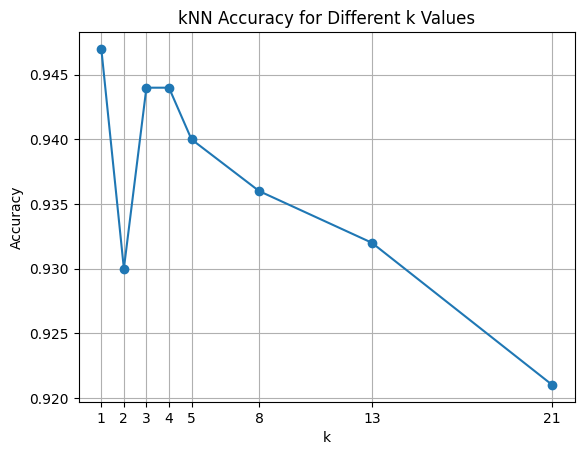

In [ ]:
# todo
# Prediction for different k values
ks = [1, 2, 3, 4, 5, 8, 13, 21]
accuracies = []
for k in ks:
    predictedY = kNN(trainX, trainY, testX, k=k)
    # calculate accuracy in correctly classified samples / total number of samples
    accuracy = np.mean(predictedY.flatten() == testY.flatten())
    accuracies.append(accuracy)
    # print(f"Accuracy for k={k}: {accuracy}")

# Plot accuracy for different k values
plt.plot(ks, accuracies, marker='o')
plt.title('kNN Accuracy for Different k Values')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(ks)
plt.grid()
plt.show()

7.) Diskutieren Sie die Ergebnisse mit Ihren Mitstudierenden!

In einigen Fällen gibt es unter Umständen keine klare Mehrheit für eine Klasse - möglicherweise sind unter den k nächsten Nachbarn ähnlich viele 3en wie 9en. Machen Sie einen Vorschlag, was in diesem Fall hilfreich für den Anwender sein könnte!

8.) BONUS: Betrachten Sie folgendes (unkommentiertes) Codefragment und beschreiben Sie dessen Wirkung:

In [105]:
from scipy.ndimage import gaussian_filter

def preprocessData(dataIn):
    dataOut = np.zeros(dataIn.shape)
    len = np.sqrt(dataIn.shape[1]).astype(np.int64)
    for i in range(0, dataIn.shape[0]):
        img = np.reshape(dataIn[i, :], [len, len]);
        img_filtered = gaussian_filter(img, sigma=1)
        dataOut[i, :] = np.reshape(img_filtered, [1, len*len]);       
    return dataOut

Führen Sie folgende Codezeilen aus und bewerten Sie erneut die Güte des Klassifikators (siehe Teil 6.). Was stellen Sie fest? Wie erklären Sie sich den Unterschied?

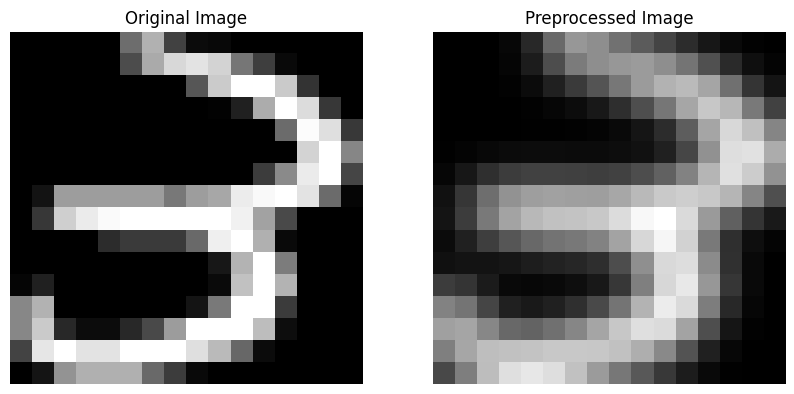

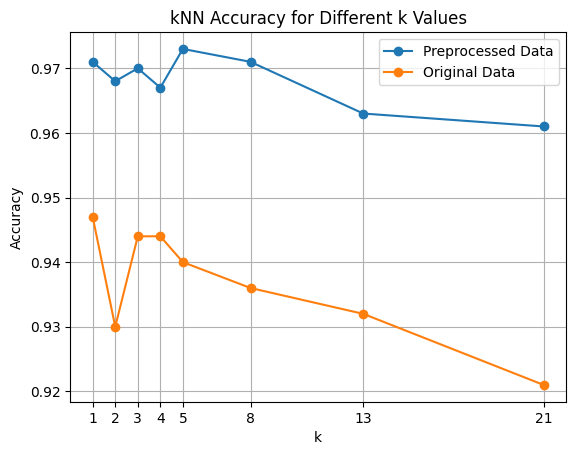

In [106]:
trainX_processed = preprocessData(trainX)
testX_processed  = preprocessData(testX)

# Visualize the effect of preprocessing on a random sample
idx = 2000
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(trainX[idx].reshape(16, 16).transpose(), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')
axes[1].imshow(trainX_processed[idx].reshape(16, 16).transpose(), cmap='gray')
axes[1].set_title("Preprocessed Image")
axes[1].axis('off')
plt.show()

accuracies_processed = []
# Accuracy
for i in ks:
    predictedY = kNN(trainX_processed, trainY, testX_processed, i)
    accuracy = np.sum(predictedY.flatten()==testY.flatten())/testY.shape[0]
    accuracies_processed.append(accuracy)
    # print(f"Accuracy for k={i}: {accuracy}")

# Plot with accuracy for preprocessed data and accuracy for non-preprocessed data
plt.plot(ks, accuracies_processed, marker='o')
plt.plot(ks, accuracies, marker='o')
plt.title('kNN Accuracy for Different k Values')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(ks)
plt.grid()
plt.legend(['Preprocessed Data', 'Original Data'])
plt.show()